 # 07_Hierarchical_Clustering

## Customer Segmentation using Hierarchical Clustering (Ward Linkage)

This notebook applies Hierarchical Clustering on the RFM customer dataset and compares different linkage methods.

## Objective

The objective of this notebook is to perform customer segmentation using Hierarchical Clustering and compare its performance with K-Means.

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

In [30]:
rfm = pd.read_csv("/content/sample_data/rfm_data.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [31]:
X = rfm[["Recency", "Frequency", "Monetary"]]

X.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
linked = linkage(X_scaled,method="ward")

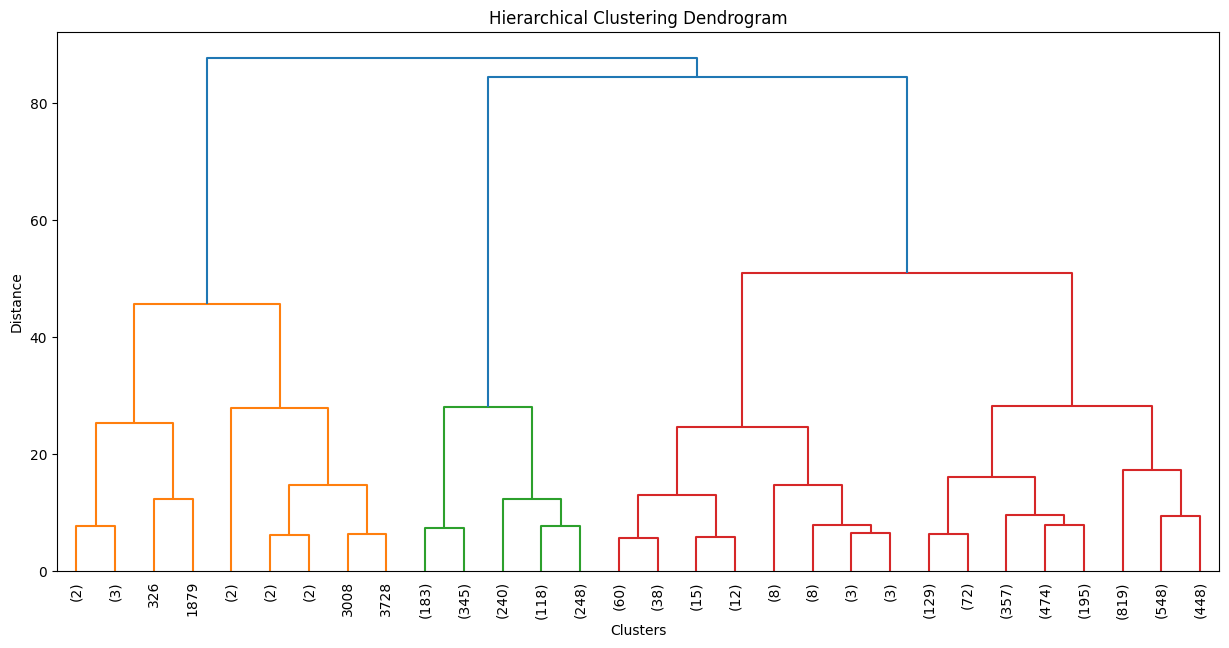

In [34]:
plt.figure(figsize=(15,7))

dendrogram(linked,truncate_mode="lastp",p=30,leaf_rotation=90,
           leaf_font_size=10,)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

In [35]:
model = AgglomerativeClustering(n_clusters=3 ,linkage= "ward")

clusters = model.fit_predict(X_scaled)

In [36]:
rfm["Cluster"] = clusters

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,0
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,2


In [37]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,3189
2,1134
1,15


In [38]:
cluster_profile = (rfm.groupby("Cluster")
                    [["Recency", "Frequency", "Monetary"]].mean().round(2))

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,40.00,4.84,2076.63
1,6.73,83.47,111780.64
2,241.41,1.64,518.62


In [39]:
score = silhouette_score(X_scaled,clusters)

print("Silhouette Score:", round(score,4))

Silhouette Score: 0.5774


In [40]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [41]:
pca_df = pd.DataFrame(X_pca,columns=["PC1","PC2"])

pca_df["Cluster"] = clusters

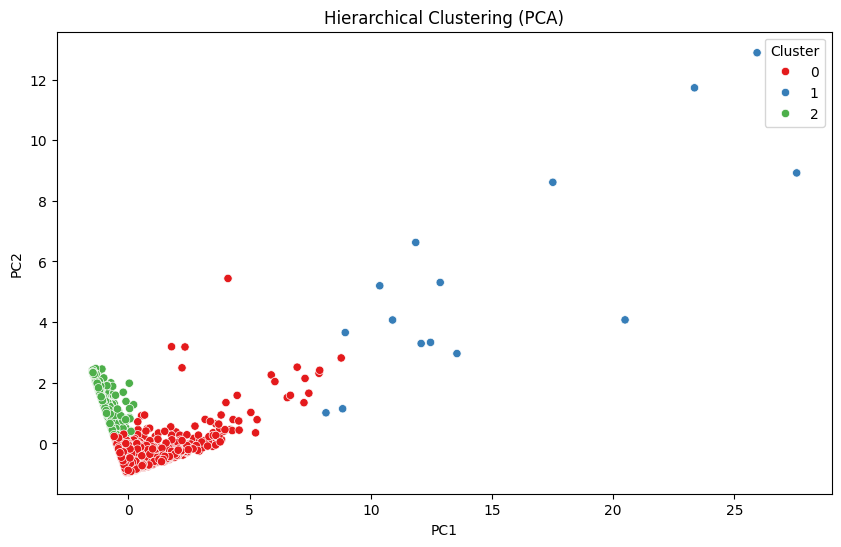

In [47]:
plt.figure(figsize=(10,6))
segment_names = {
    0: "Regular",
    1: "VIP",
    2: "At-Risk"
}
pca_df["Segment"] = pca_df["Cluster"].map(segment_names)

sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="Set1")
plt.title("Hierarchical Clustering (PCA)")

plt.show()

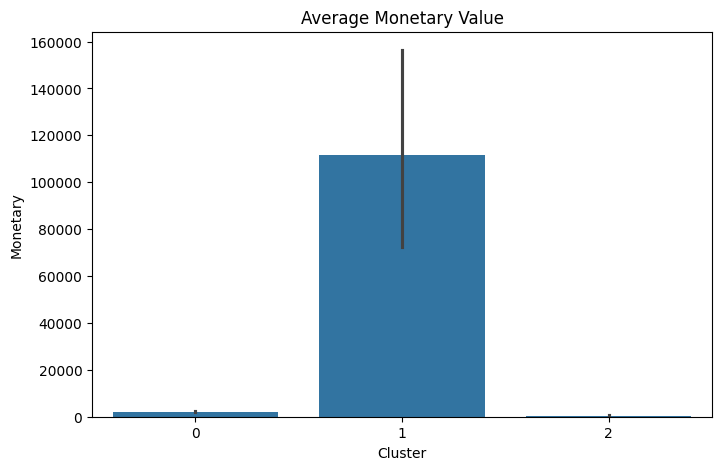

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(data=rfm,x="Cluster",y="Monetary")
plt.title("Average Monetary Value")

plt.show()

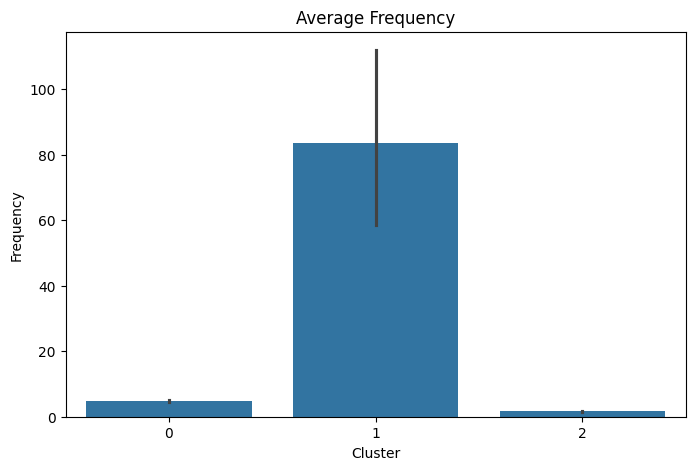

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(data=rfm,x="Cluster",y="Frequency")
plt.title("Average Frequency")

plt.show()

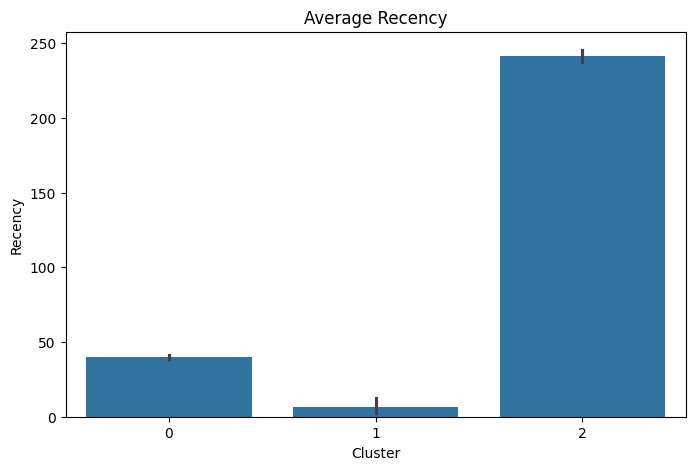

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(data=rfm,x="Cluster",y="Recency")
plt.title("Average Recency")

plt.show()

In [46]:
methods = ["ward", "complete", "average", "single"]

for method in methods:

    model = AgglomerativeClustering(n_clusters=3,linkage=method )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)
    print(f"{method:<10} : {score:.4f}")

ward       : 0.5774
complete   : 0.9417
average    : 0.9270
single     : 0.9427


## Observation

Although Single, Complete, and Average Linkage produced very high silhouette scores, they created extremely imbalanced clusters (e.g., one cluster containing almost all customers).

Ward Linkage produced the most balanced and interpretable clusters, making it more suitable for customer segmentation.

## Conclusion

Ward Linkage achieved a Silhouette Score of **0.5774**, outperforming the K-Means model (0.5097) while producing meaningful customer segments.

Single, Complete, and Average Linkage produced higher silhouette scores but suffered from severe cluster imbalance, making them unsuitable for business applications.

Therefore, Ward Linkage is the preferred Hierarchical Clustering method for this dataset.